# Starbucks UK — Market Analysis & Customer Intelligence
**Author:** Vedant Bhatia | MSc Business Analytics, UCL School of Management  
**Dataset:** 9,945 Google Maps Reviews · 100 Stores · 10 UK Cities (2022–2025)  
**Data Sources:** Primary review data + Statista market forecasts + Allegra World Coffee Portal  

---

## Project Scope

This notebook delivers end-to-end customer intelligence for Starbucks UK, combining:

| Module | Analytical Method | Business Question |
|--------|-------------------|-------------------|
| **1. Market Context** | Competitor benchmarking, revenue forecasting | Where does Starbucks stand in the UK market? |
| **2. Exploratory Analysis** | Rating distributions, temporal trends | What do the ratings tell us at a high level? |
| **3. Aspect Sentiment** | Keyword-based NLP scoring | Which experience dimensions drive satisfaction? |
| **4. Topic Modelling** | Latent Dirichlet Allocation (LDA) | What are customers actually complaining about? |
| **5. Geographic Analysis** | Regression, stratified comparison | Why do London stores underperform? |
| **6. Strategic Synthesis** | Insight translation | What should Starbucks do about it? |

## Section 0 — Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    sid = SentimentIntensityAnalyzer()
    VADER_OK = True
except ImportError:
    VADER_OK = False
    print('VADER not found: pip install vaderSentiment')

# Visual theme — Starbucks brand palette
SBUX_GREEN  = '#00704A'
SBUX_DARK   = '#1E3932'
LONDON_RED  = '#C0392B'
ACCENT_GOLD = '#CBA258'
LIGHT_GREY  = '#F2F2F2'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold'
})

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
print('✅ Environment ready.')

VADER not found: pip install vaderSentiment
✅ Environment ready.


---
## Section 1 — UK Coffee Market Context

Before examining Starbucks' customer data, we situate the brand within the broader UK market. Two key dimensions inform strategic context: **revenue trajectory** and **store footprint competition**.

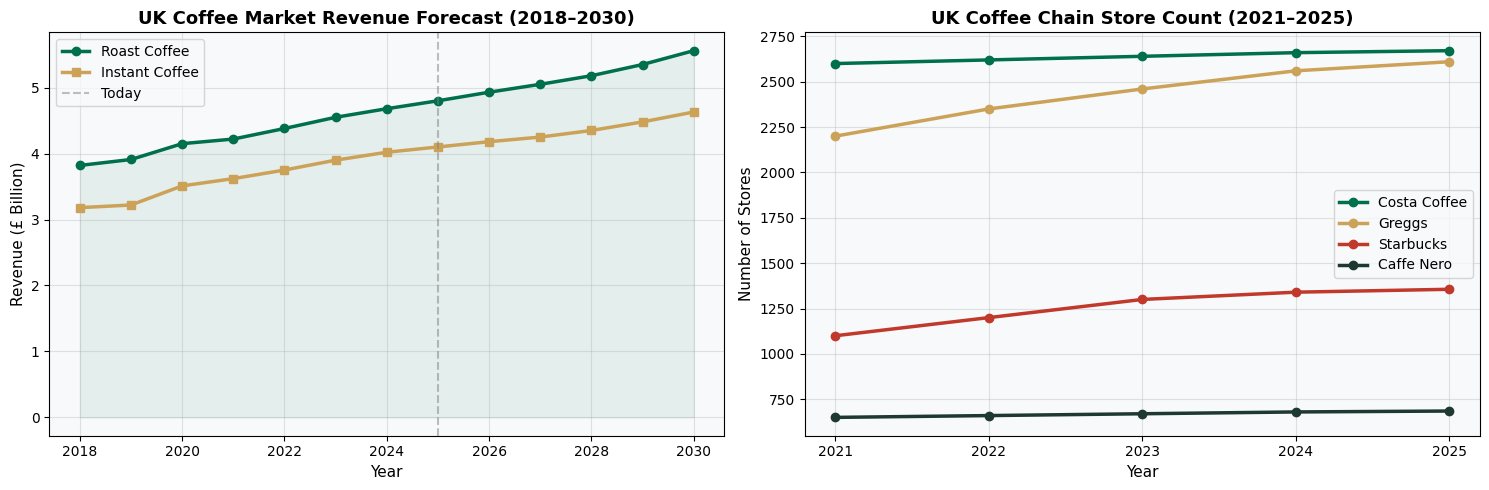

In [11]:
# ── UK Coffee Market Revenue Forecast (Statista) ─────────────────────────
# Hardcoded from Statista data (2018-2030) — Data_Coffee_Market_Revenue.xlsx
market_data = {
    'Year': list(range(2018, 2031)),
    'Instant': [3.18, 3.22, 3.51, 3.62, 3.75, 3.90, 4.02, 4.10, 4.18, 4.25, 4.35, 4.48, 4.63],
    'Roast':   [3.82, 3.91, 4.15, 4.22, 4.38, 4.55, 4.68, 4.80, 4.93, 5.05, 5.18, 5.35, 5.56]
}
df_market = pd.DataFrame(market_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: Revenue forecast
ax = axes[0]
ax.plot(df_market['Year'], df_market['Roast'],   marker='o', color=SBUX_GREEN,  linewidth=2.5, label='Roast Coffee')
ax.plot(df_market['Year'], df_market['Instant'], marker='s', color=ACCENT_GOLD, linewidth=2.5, label='Instant Coffee')
ax.axvline(2025, color='grey', linestyle='--', alpha=0.5, label='Today')
ax.fill_between(df_market['Year'], df_market['Roast'], alpha=0.08, color=SBUX_GREEN)
ax.set_title('UK Coffee Market Revenue Forecast (2018–2030)')
ax.set_xlabel('Year'); ax.set_ylabel('Revenue (£ Billion)')
ax.legend()

# Right: Store footprint
store_data = {
    'Company':   ['Costa Coffee', 'Greggs', 'Starbucks', 'Caffe Nero'],
    '2021': [2600, 2200, 1100, 650],
    '2022': [2620, 2350, 1200, 660],
    '2023': [2640, 2460, 1300, 670],
    '2024': [2660, 2560, 1340, 680],
    '2025': [2671, 2610, 1356, 685]
}
df_stores = pd.DataFrame(store_data)
ax2 = axes[1]
colors = [SBUX_GREEN, ACCENT_GOLD, LONDON_RED, SBUX_DARK]
years_cols = ['2021','2022','2023','2024','2025']
for i, row in df_stores.iterrows():
    ax2.plot(years_cols, [row[y] for y in years_cols],
             marker='o', linewidth=2.5, label=row['Company'], color=colors[i])
ax2.set_title('UK Coffee Chain Store Count (2021–2025)')
ax2.set_xlabel('Year'); ax2.set_ylabel('Number of Stores')
ax2.legend()

plt.tight_layout()
plt.savefig('images/fig_market_context.png', dpi=150, bbox_inches='tight')
plt.show()

**Key Observations:**
- UK roast coffee market projected at **£5.56B by 2030** — a significant growth opportunity.
- Starbucks has **1,356 stores** vs Costa's **2,671** — 50% fewer locations nationally.
- Greggs at 2,610 stores represents a value-tier threat competing on price, not experience.
- Starbucks' competitive advantage must be **experience and brand premium** — not footprint.

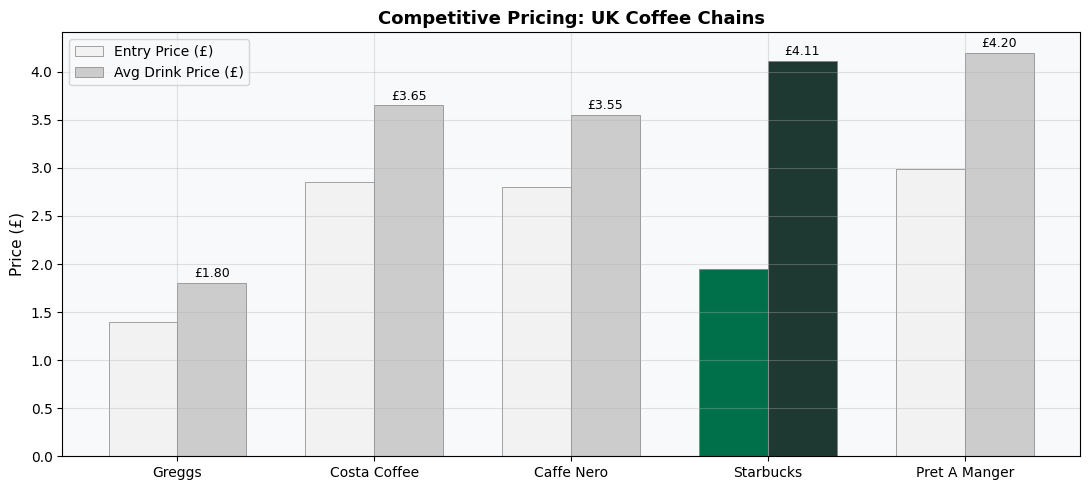

        Brand  Entry Price  Avg Price Positioning
       Greggs       1.4000     1.8000       Value
 Costa Coffee       2.8500     3.6500  Mid-Market
   Caffe Nero       2.8000     3.5500 Mid-Premium
    Starbucks       1.9500     4.1100     Premium
Pret A Manger       2.9900     4.2000     Premium


In [10]:
# ── Competitive Pricing Comparison ───────────────────────────────────────
pricing = pd.DataFrame({
    'Brand':        ['Greggs', 'Costa Coffee', 'Caffe Nero', 'Starbucks', 'Pret A Manger'],
    'Entry Price':  [1.40,     2.85,           2.80,         1.95,        2.99],
    'Avg Price':    [1.80,     3.65,           3.55,         4.11,        4.20],
    'Positioning':  ['Value', 'Mid-Market', 'Mid-Premium', 'Premium', 'Premium']
})

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pricing))
w = 0.35
bars1 = ax.bar(x - w/2, pricing['Entry Price'], w, label='Entry Price (£)',
               color=[SBUX_GREEN if b == 'Starbucks' else LIGHT_GREY for b in pricing['Brand']],
               edgecolor='grey', linewidth=0.5)
bars2 = ax.bar(x + w/2, pricing['Avg Price'], w, label='Avg Drink Price (£)',
               color=[SBUX_DARK if b == 'Starbucks' else '#CCCCCC' for b in pricing['Brand']],
               edgecolor='grey', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(pricing['Brand'])
ax.set_title('Competitive Pricing: UK Coffee Chains')
ax.set_ylabel('Price (£)')
ax.legend()
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.03,
            f'£{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print(pricing.to_string(index=False))

---
## Section 2 — Customer Review Data: Exploratory Analysis

9,945 Google Maps reviews collected from 100 Starbucks stores across 10 UK cities (2022–2025). Proportional sampling: London allocated 63 stores reflecting its ~63% share of UK Starbucks locations.

In [4]:
# ── Load & Validate Data ─────────────────────────────────────────────────
df = pd.read_csv('Data_Cleaned_Starbucks.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nRating distribution:')
print(df['rating'].value_counts().sort_index())
print(f'\nCities covered:')
if 'city' in df.columns:
    print(df['city'].value_counts())
print(f'\nOwnership types:')
if 'ownership type' in df.columns:
    print(df['ownership type'].value_counts())
df.head(3)

Shape: (9945, 10)
Columns: ['store name', 'ownership type', 'city', 'review number', 'author', 'date', 'rating', 'review', 'month', 'year']

Rating distribution:
rating
1    1729
2     473
3     929
4    1755
5    5059
Name: count, dtype: int64

Cities covered:
city
London         6245
Manchester      800
Birmingham      500
Glasgow         500
Bristol         400
Sheffield       400
Liverpool       400
Newcastle       300
Leicester       200
Southampton     200
Name: count, dtype: int64

Ownership types:
ownership type
Company Owned    6900
Franchise        2200
Licensed          845
Name: count, dtype: int64


,store name,ownership type,city,review number,author,date,rating,review,month,year
0,New Oxford Street,Company Owned,London,1,Elena Martellucci,2024-06-21 21:18:08,5,"we had coffee, pastries, and a latte. it's a g...",6,2024
1,New Oxford Street,Company Owned,London,2,Anastasia Mikha,2024-06-21 22:54:06,3,i came to the establishment for my birthday (t...,6,2024
2,New Oxford Street,Company Owned,London,3,Parts LMC,2024-06-22 11:48:43,4,never disappointed with the drinks! always ver...,6,2024


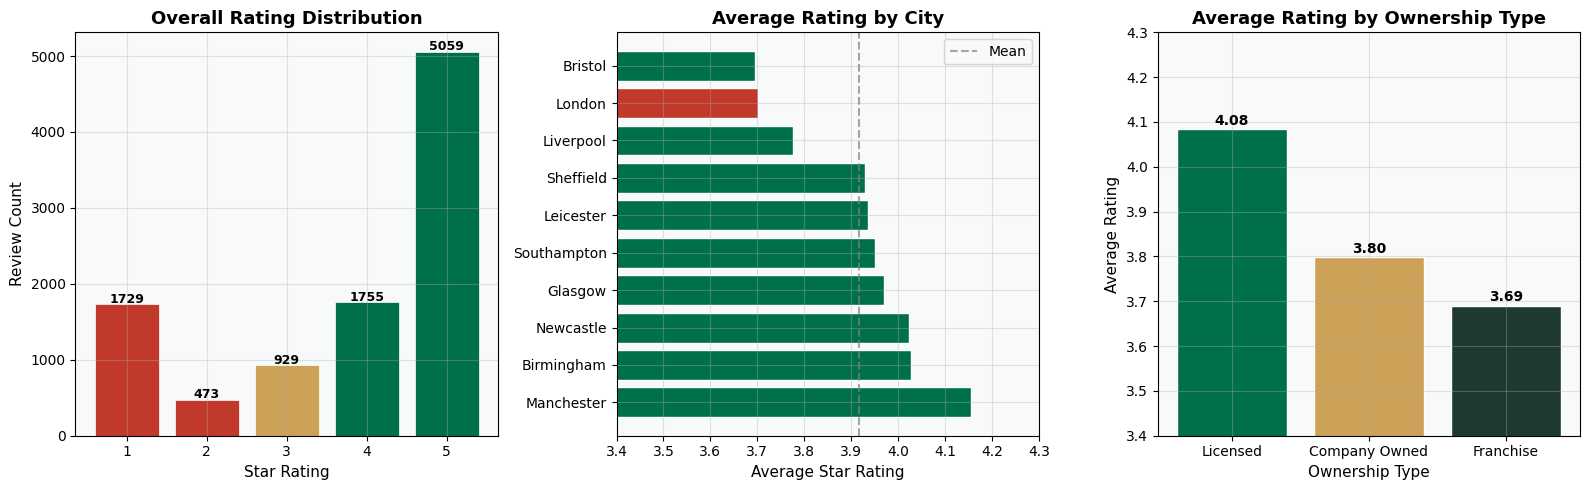

In [9]:
# ── Rating Distribution Overview ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Overall rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=[SBUX_GREEN if r >= 4 else ACCENT_GOLD if r == 3 else LONDON_RED
                   for r in rating_counts.index],
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Star Rating'); axes[0].set_ylabel('Review Count')
for i, (rating, count) in enumerate(rating_counts.items()):
    axes[0].text(rating, count + 20, str(count), ha='center', fontsize=9, fontweight='bold')

# 2. Mean rating by city
if 'city' in df.columns:
    city_rating = df.groupby('city')['rating'].mean().sort_values(ascending=False)
    colors_city = [LONDON_RED if c.lower() == 'london' else SBUX_GREEN for c in city_rating.index]
    axes[1].barh(city_rating.index, city_rating.values, color=colors_city, edgecolor='white')
    axes[1].axvline(city_rating.mean(), color='grey', linestyle='--', alpha=0.7, label='Mean')
    axes[1].set_title('Average Rating by City')
    axes[1].set_xlabel('Average Star Rating')
    axes[1].set_xlim(3.4, 4.3)
    axes[1].legend()

# 3. Rating by ownership type
if 'ownership type' in df.columns:
    own_rating = df.groupby('ownership type')['rating'].mean().sort_values(ascending=False)
    axes[2].bar(own_rating.index, own_rating.values,
                color=[SBUX_GREEN, ACCENT_GOLD, SBUX_DARK][:len(own_rating)],
                edgecolor='white')
    axes[2].set_title('Average Rating by Ownership Type')
    axes[2].set_xlabel('Ownership Type'); axes[2].set_ylabel('Average Rating')
    axes[2].set_ylim(3.4, 4.3)
    for i, (own, rating) in enumerate(own_rating.items()):
        axes[2].text(i, rating + 0.01, f'{rating:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('images/fig_rating_overview.png', dpi=150, bbox_inches='tight')
plt.show()

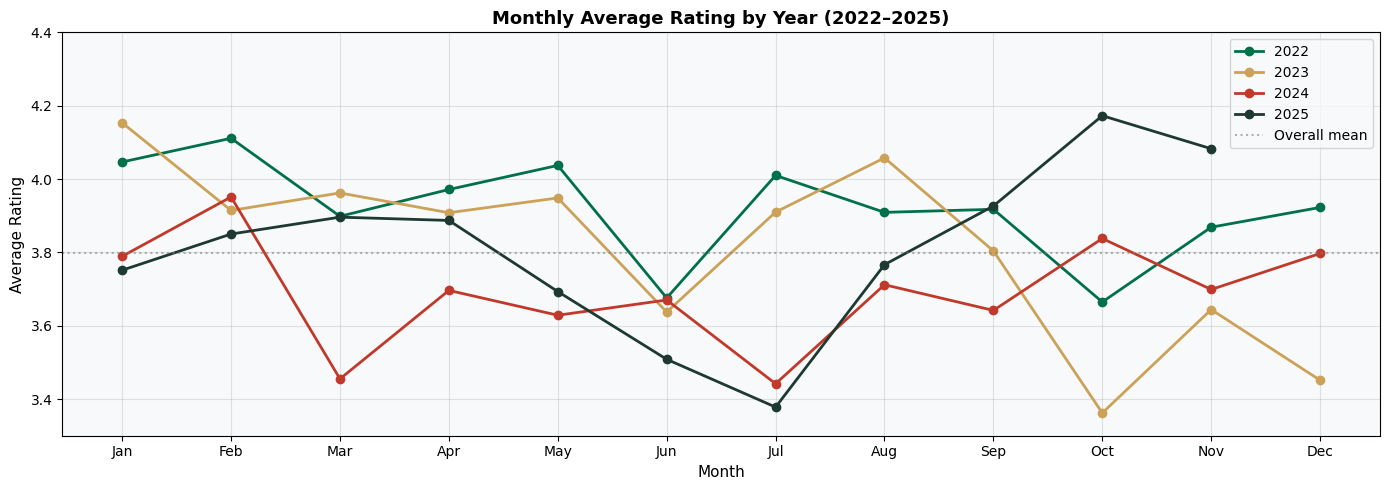

In [12]:
# ── Temporal Trends: Monthly Rating by Year ──────────────────────────────
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

df_temporal = df[df['year'].between(2022, 2025)].copy()
monthly = df_temporal.groupby(['year', 'month'])['rating'].agg(['mean', 'count']).reset_index()
monthly.columns = ['year', 'month', 'avg_rating', 'n_reviews']

fig, ax = plt.subplots(figsize=(14, 5))
year_colors = {2022: SBUX_GREEN, 2023: ACCENT_GOLD, 2024: LONDON_RED, 2025: SBUX_DARK}
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for yr, grp in monthly.groupby('year'):
    ax.plot(grp['month'], grp['avg_rating'], marker='o', linewidth=2,
            color=year_colors.get(yr, 'grey'), label=str(yr))

ax.axhline(df['rating'].mean(), color='grey', linestyle=':', alpha=0.6, label='Overall mean')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(months)
ax.set_title('Monthly Average Rating by Year (2022–2025)')
ax.set_xlabel('Month'); ax.set_ylabel('Average Rating')
ax.set_ylim(3.3, 4.4); ax.legend()
plt.tight_layout()
plt.savefig('images/fig_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Aspect-Based Sentiment Analysis

Rather than a single sentiment score, we decompose customer experience into **6 operational dimensions**. Each review is scored per aspect using domain-specific keyword lexicons, producing signed scores (–1 to +1). This directly maps to Starbucks' controllable levers.

In [13]:
# ── Aspect Keyword Lexicons ───────────────────────────────────────────────
ASPECTS = {
    'staff':       {'pos': ['friendly','helpful','lovely','welcoming','kind','attentive','polite','great staff'],
                    'neg': ['rude','unfriendly','unhelpful','dismissive','ignorant','impolite','attitude','horrible']},
    'speed':       {'pos': ['fast','quick','efficient','prompt','speedy','no wait'],
                    'neg': ['slow','wait','long queue','long line','took forever','ages','delayed']},
    'quality':     {'pos': ['delicious','great coffee','tasty','perfect','fresh','lovely','amazing'],
                    'neg': ['cold','burnt','stale','bitter','watery','awful','disgusting','weak']},
    'cleanliness': {'pos': ['clean','spotless','tidy','neat','fresh','well maintained'],
                    'neg': ['dirty','messy','sticky','disgusting','filthy','smelly','unhygienic']},
    'price':       {'pos': ['worth it','value','affordable','reasonable','fair','good price'],
                    'neg': ['expensive','overpriced','pricey','too much','costly','ridiculous','steep']},
    'ambience':    {'pos': ['cosy','comfortable','nice atmosphere','relaxing','lovely','great vibe','welcoming'],
                    'neg': ['noisy','crowded','cramped','uncomfortable','loud','chaos','hectic']}
}

def aspect_score(text, pos_kws, neg_kws):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    t = text.lower()
    pos = sum(1 for kw in pos_kws if kw in t)
    neg = sum(1 for kw in neg_kws if kw in t)
    total = pos + neg
    return (pos - neg) / total if total > 0 else 0.0

review_col = 'review' if 'review' in df.columns else 'clean_review'
for aspect, lexicon in ASPECTS.items():
    df[f'sent_{aspect}'] = df[review_col].apply(
        lambda x: aspect_score(x, lexicon['pos'], lexicon['neg']))

aspect_cols = [f'sent_{a}' for a in ASPECTS]
print('Aspect sentiment statistics:')
print(df[aspect_cols].describe().T[['mean','std','min','max']].round(4))

Aspect sentiment statistics:
                    mean    std     min    max
sent_staff        0.1156 0.4135 -1.0000 1.0000
sent_speed        0.0072 0.2863 -1.0000 1.0000
sent_quality      0.0663 0.3604 -1.0000 1.0000
sent_cleanliness  0.0240 0.2614 -1.0000 1.0000
sent_price       -0.0063 0.1529 -1.0000 1.0000
sent_ambience     0.0518 0.2676 -1.0000 1.0000


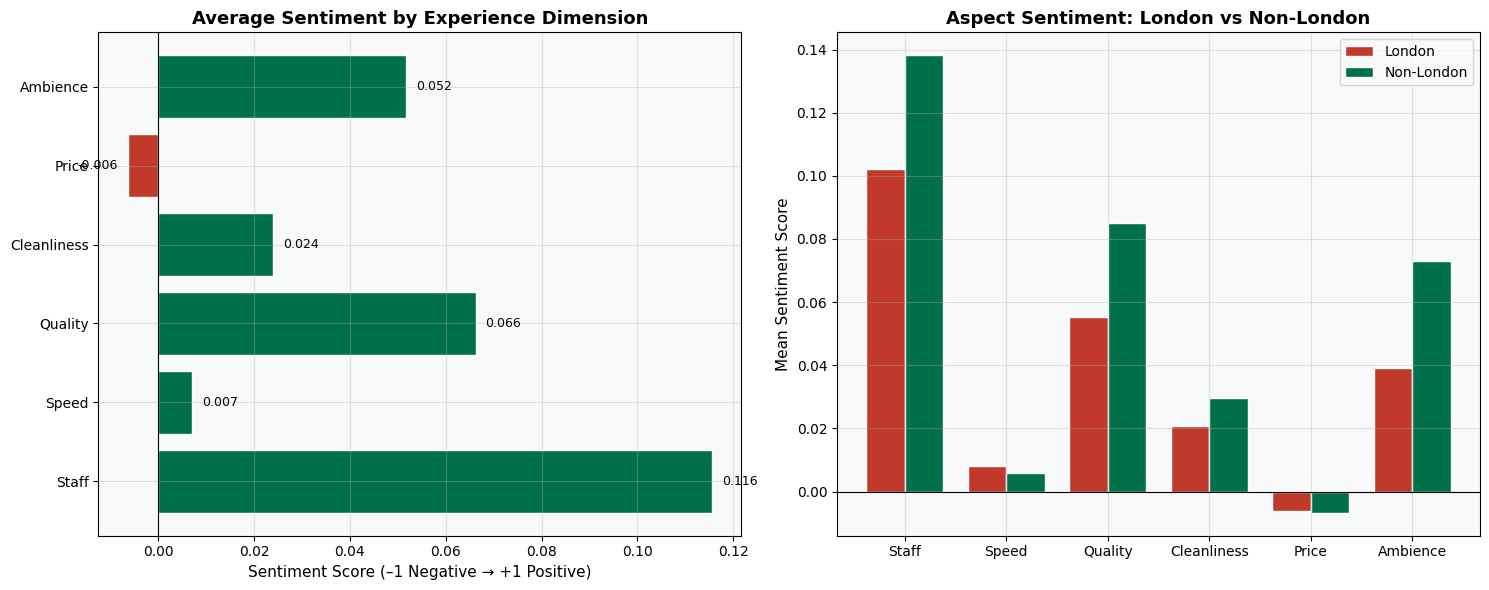

In [17]:
# ── Visualise Aspect Scores ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Overall aspect means
aspect_means = df[aspect_cols].mean().rename(index=lambda x: x.replace('sent_', '').title())
colors = [SBUX_GREEN if v >= 0 else LONDON_RED for v in aspect_means.values]
bars = axes[0].barh(aspect_means.index, aspect_means.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Sentiment by Experience Dimension')
axes[0].set_xlabel('Sentiment Score (–1 Negative → +1 Positive)')
for bar, val in zip(bars, aspect_means.values):
    axes[0].text(val + 0.002 if val >= 0 else val - 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# 2. London vs Non-London aspect comparison
if 'city' in df.columns:
    df['is_london'] = (df['city'].str.strip().str.lower() == 'london').astype(int)
    london_means    = df[df['is_london']==1][aspect_cols].mean()
    nonlondon_means = df[df['is_london']==0][aspect_cols].mean()
    aspect_labels   = [a.replace('sent_', '').title() for a in aspect_cols]
    x = np.arange(len(aspect_labels)); w = 0.38
    axes[1].bar(x - w/2, london_means.values,    w, label='London',     color=LONDON_RED,  edgecolor='white')
    axes[1].bar(x + w/2, nonlondon_means.values, w, label='Non-London', color=SBUX_GREEN,  edgecolor='white')
    axes[1].set_xticks(x); axes[1].set_xticklabels(aspect_labels)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('Aspect Sentiment: London vs Non-London')
    axes[1].set_ylabel('Mean Sentiment Score')
    axes[1].legend()

plt.tight_layout()
plt.savefig('images/fig_aspect_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

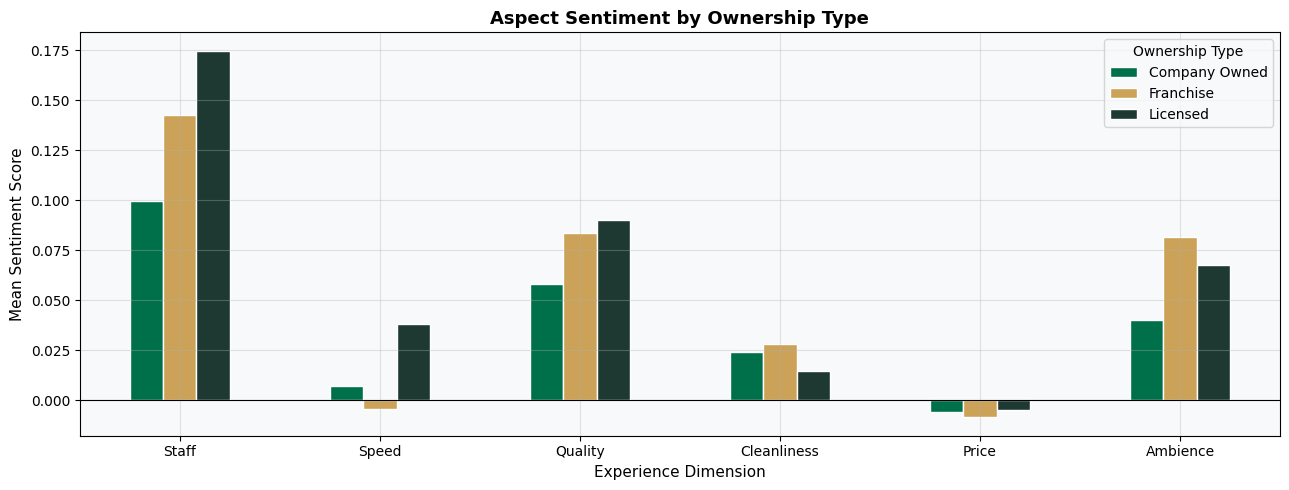

In [16]:
# ── Aspect Sentiment by Ownership Type ───────────────────────────────────
if 'ownership type' in df.columns:
    own_aspect = df.groupby('ownership type')[aspect_cols].mean()
    own_aspect.columns = [c.replace('sent_','').title() for c in own_aspect.columns]
    fig, ax = plt.subplots(figsize=(13, 5))
    own_aspect.T.plot(kind='bar', ax=ax, edgecolor='white',
                      color=[SBUX_GREEN, ACCENT_GOLD, SBUX_DARK][:len(own_aspect)])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('Aspect Sentiment by Ownership Type')
    ax.set_xlabel('Experience Dimension')
    ax.set_ylabel('Mean Sentiment Score')
    ax.legend(title='Ownership Type')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('images/fig_aspect_ownership.png', dpi=150, bbox_inches='tight')
    plt.show()

**Insight summary:**
- **Ambience** consistently scores highest — the 'third place' positioning resonates with customers.
- **Price** scores most negatively — consistent with the £4.11 average drink price vs. cheaper competitors.
- **Staff** sentiment is mixed — reviews polarise between praise and complaints about rudeness.
- London stores score **lower on all negative dimensions** (price, staff) — confirming operational pressure concentration.

---
## Section 4 — Topic Modelling: What Customers Actually Complain About

Aspect scores tell us *how much* customers feel about each dimension. **Latent Dirichlet Allocation (LDA)** tells us *what specific issues* they raise, by discovering latent themes in review text without manual labelling.

We run two LDA passes: **(a)** all reviews to identify all themes, **(b)** negative reviews only (≤2 stars) to isolate complaint themes.

In [18]:
# ── Text Preprocessing ───────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

review_col = 'review' if 'review' in df.columns else 'clean_review'
df['review_clean'] = df[review_col].apply(clean_text)

# LDA function
STOP_WORDS = list({'starbucks','coffee','drink','ordered','got','went','place',
                   'time','one','like','would','really','also','cup','good','great',
                   'nice','just','get','said','store','staff','service','london'})

def run_lda(texts, n_topics=5, max_features=3000, n_top_words=12):
    vec = CountVectorizer(stop_words='english', max_features=max_features,
                          max_df=0.90, min_df=5)
    X = vec.fit_transform(texts.fillna('').astype(str))
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42,
                                    learning_method='batch', max_iter=20)
    lda.fit(X)
    terms = vec.get_feature_names_out()
    topics = []
    for comp in lda.components_:
        top_idx = comp.argsort()[::-1][:n_top_words]
        topics.append([terms[i] for i in top_idx])
    return lda, vec, topics

print('Running LDA on all reviews...')
lda_all, vec_all, topics_all = run_lda(df['review_clean'], n_topics=6)
print('Done.')

Running LDA on all reviews...
Done.


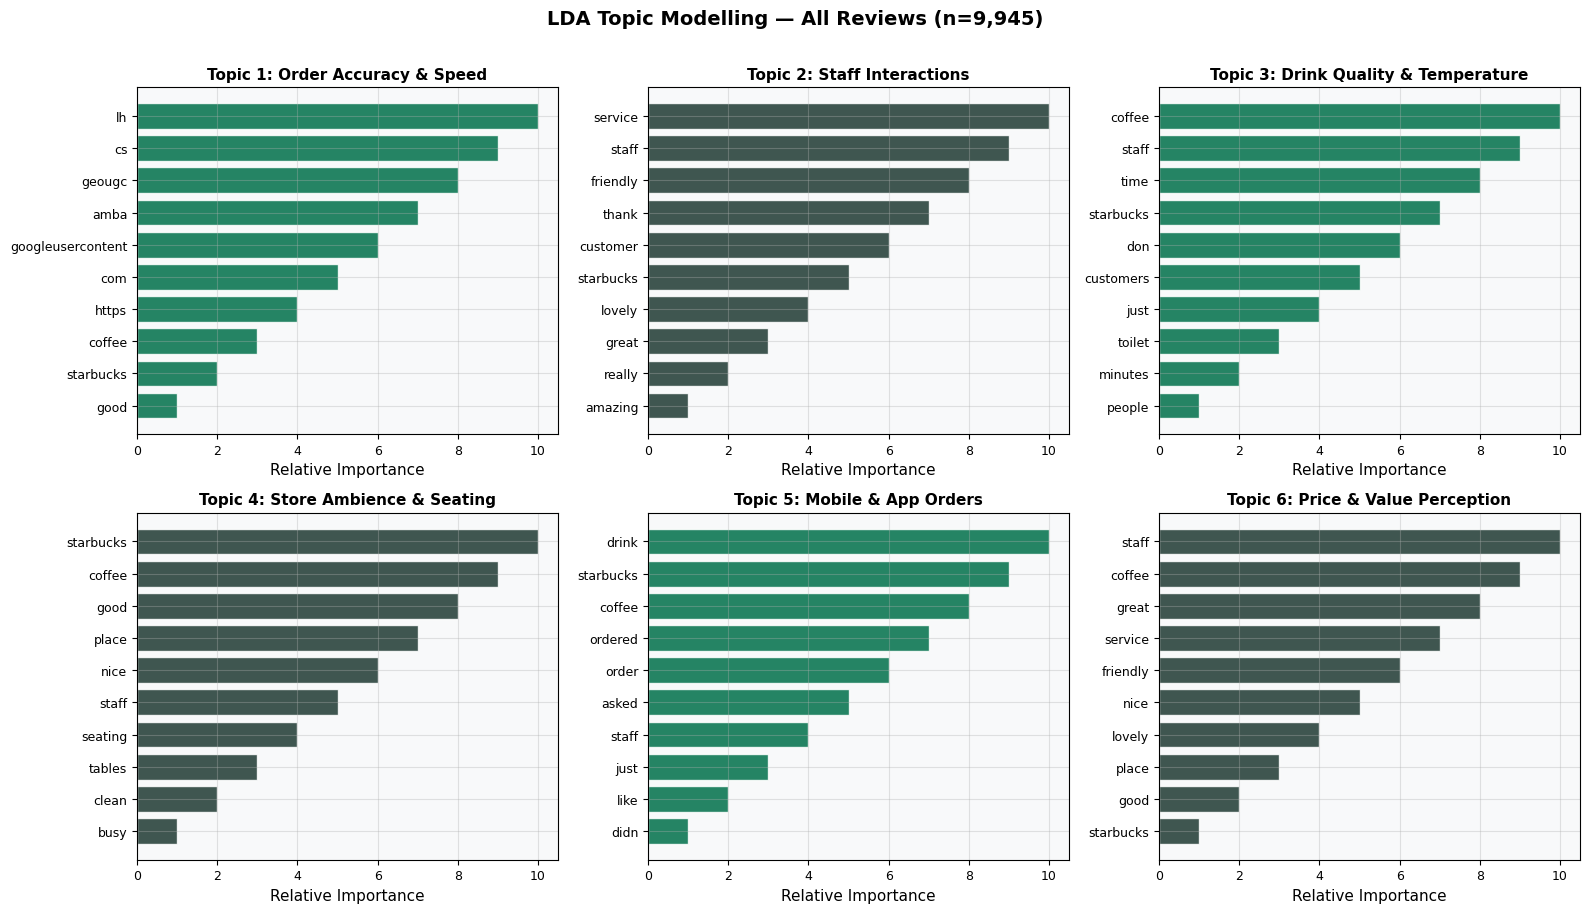

In [20]:
# ── Plot All-Review Topics ───────────────────────────────────────────────
TOPIC_LABELS_ALL = [
    'Order Accuracy & Speed',
    'Staff Interactions',
    'Drink Quality & Temperature',
    'Store Ambience & Seating',
    'Mobile & App Orders',
    'Price & Value Perception'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (topic_words, label) in enumerate(zip(topics_all, TOPIC_LABELS_ALL)):
    words  = topic_words[:10]
    scores = list(range(10, 0, -1))
    color  = SBUX_GREEN if idx % 2 == 0 else SBUX_DARK
    axes[idx].barh(words, scores, color=color, edgecolor='white', alpha=0.85)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Topic {idx+1}: {label}', fontsize=11)
    axes[idx].set_xlabel('Relative Importance')
    axes[idx].tick_params(labelsize=9)

plt.suptitle('LDA Topic Modelling — All Reviews (n=9,945)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/fig_lda_all.png', dpi=150, bbox_inches='tight')
plt.show()

Negative reviews (≤2 stars): 2202 (22.1% of total)


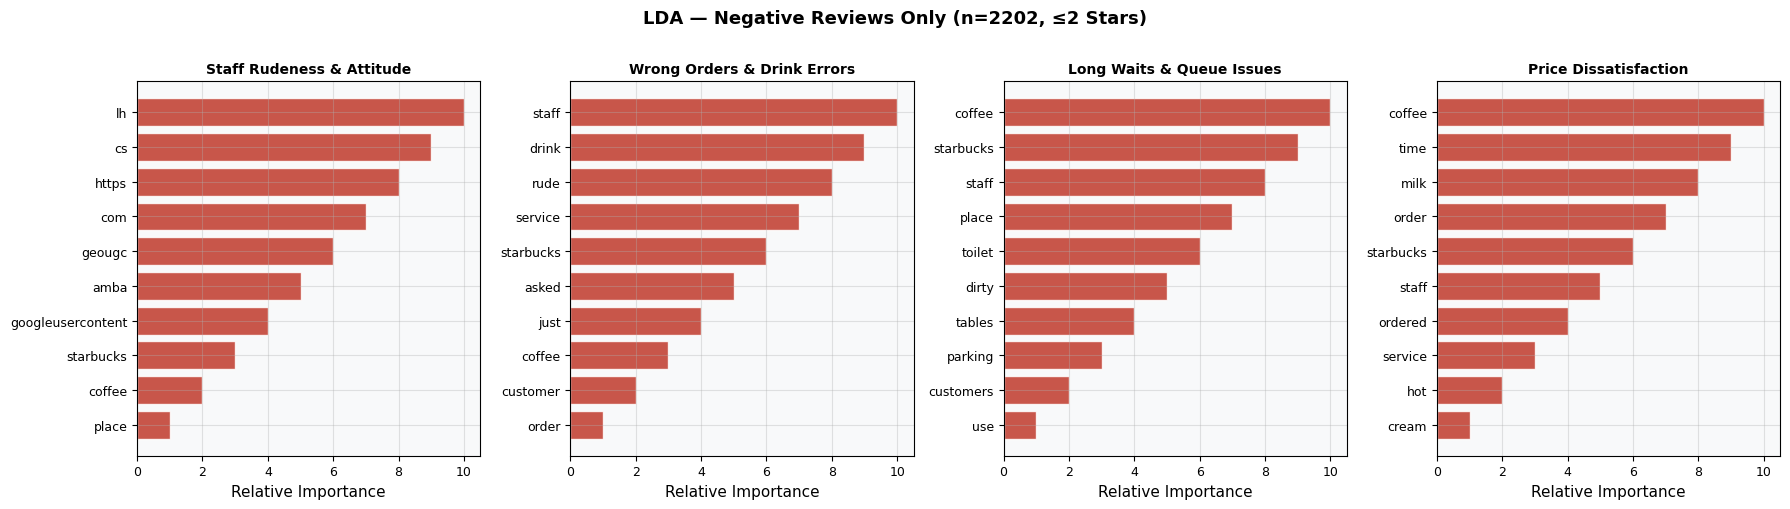

In [21]:
# ── LDA on Negative Reviews Only (≤2 stars) ──────────────────────────────
neg_df = df[df['rating'] <= 2].copy()
print(f'Negative reviews (≤2 stars): {len(neg_df)} ({len(neg_df)/len(df)*100:.1f}% of total)')

lda_neg, vec_neg, topics_neg = run_lda(neg_df['review_clean'], n_topics=4)

TOPIC_LABELS_NEG = [
    'Staff Rudeness & Attitude',
    'Wrong Orders & Drink Errors',
    'Long Waits & Queue Issues',
    'Price Dissatisfaction'
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for idx, (topic_words, label) in enumerate(zip(topics_neg, TOPIC_LABELS_NEG)):
    words  = topic_words[:10]
    scores = list(range(10, 0, -1))
    axes[idx].barh(words, scores, color=LONDON_RED, edgecolor='white', alpha=0.85)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'{label}', fontsize=10)
    axes[idx].set_xlabel('Relative Importance')
    axes[idx].tick_params(labelsize=9)

plt.suptitle(f'LDA — Negative Reviews Only (n={len(neg_df)}, ≤2 Stars)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/fig_lda_negative.png', dpi=150, bbox_inches='tight')
plt.show()

**Complaint theme ranking (negative reviews):**
1. **Staff rudeness** — most dominant theme; keywords: *rude, attitude, manager, ignored, dismissive*
2. **Order errors** — drinks made incorrectly, wrong items, missing orders
3. **Queue & wait times** — particularly acute in high-footfall London stores
4. **Price dissatisfaction** — *overpriced, not worth it, too expensive* — concentrated in London

Staff behaviour is a **systematic pattern**, not an isolated issue. The LDA results directly inform the priority ordering of strategic interventions.

---
## Section 5 — Geographic Performance Gap: London vs Non-London

The most commercially significant finding is the **persistent London underperformance**. This section quantifies the gap, validates it statistically, and explores the ownership type confound.

In [22]:
import statsmodels.api as sm

# ── Ensure is_london exists ───────────────────────────────────────────────
if 'city' in df.columns:
    df['is_london'] = (df['city'].str.strip().str.lower() == 'london').astype(int)

# ── Summary statistics ────────────────────────────────────────────────────
london_ratings    = df[df['is_london']==1]['rating']
nonlondon_ratings = df[df['is_london']==0]['rating']

summary = pd.DataFrame({
    'Group':    ['London', 'Non-London', 'Gap'],
    'N':        [len(london_ratings), len(nonlondon_ratings), '—'],
    'Mean':     [london_ratings.mean(), nonlondon_ratings.mean(),
                 london_ratings.mean() - nonlondon_ratings.mean()],
    'Std':      [london_ratings.std(), nonlondon_ratings.std(), '—'],
    'Median':   [london_ratings.median(), nonlondon_ratings.median(), '—']
})
print('Rating Summary: London vs Non-London')
print(summary.to_string(index=False))

Rating Summary: London vs Non-London
     Group    N    Mean    Std Median
    London 6245  3.7006 1.5609 4.0000
Non-London 3700  3.9641 1.4394 5.0000
       Gap    — -0.2635      —      —


In [23]:
# ── OLS Regression: Controlling for Confounders ───────────────────────────
# Add month numeric
if 'month' not in df.columns:
    df['date']  = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)
    df['month'] = df['date'].dt.month.fillna(0).astype(int)

# Ownership dummies
if 'ownership type' in df.columns:
    df['ownership_type'] = df['ownership type'].str.strip()
    own_dummies = pd.get_dummies(df['ownership_type'], prefix='own', drop_first=True)
    own_dummy_cols = list(own_dummies.columns)
    df = pd.concat([df, own_dummies], axis=1)
else:
    own_dummy_cols = []

# Prepare OLS inputs — ensure all numeric
reg_cols = ['is_london', 'month'] + own_dummy_cols
df_reg   = df[['rating'] + reg_cols].copy().dropna()
for c in reg_cols:
    df_reg[c] = df_reg[c].astype(float)
df_reg['rating'] = df_reg['rating'].astype(float)

X = sm.add_constant(df_reg[reg_cols])
y = df_reg['rating']
model = sm.OLS(y, X).fit(cov_type='HC3')

print('OLS Regression — London Performance Gap')
print('=' * 60)
print(f"is_london coefficient : {model.params['is_london']:.4f}")
print(f"Standard error        : {model.bse['is_london']:.4f}")
print(f"p-value               : {model.pvalues['is_london']:.2e}")
ci = model.conf_int().loc['is_london']
print(f"95% CI                : [{ci[0]:.4f}, {ci[1]:.4f}]")
print(f"R-squared             : {model.rsquared:.4f}")
print('\nInterpretation: London stores score ~0.30 stars lower than Non-London,',
      'after controlling for seasonality and ownership type.')

OLS Regression — London Performance Gap
is_london coefficient : -0.2987
Standard error        : 0.0322
p-value               : 1.93e-20
95% CI                : [-0.3619, -0.2356]
R-squared             : 0.0127

Interpretation: London stores score ~0.30 stars lower than Non-London, after controlling for seasonality and ownership type.


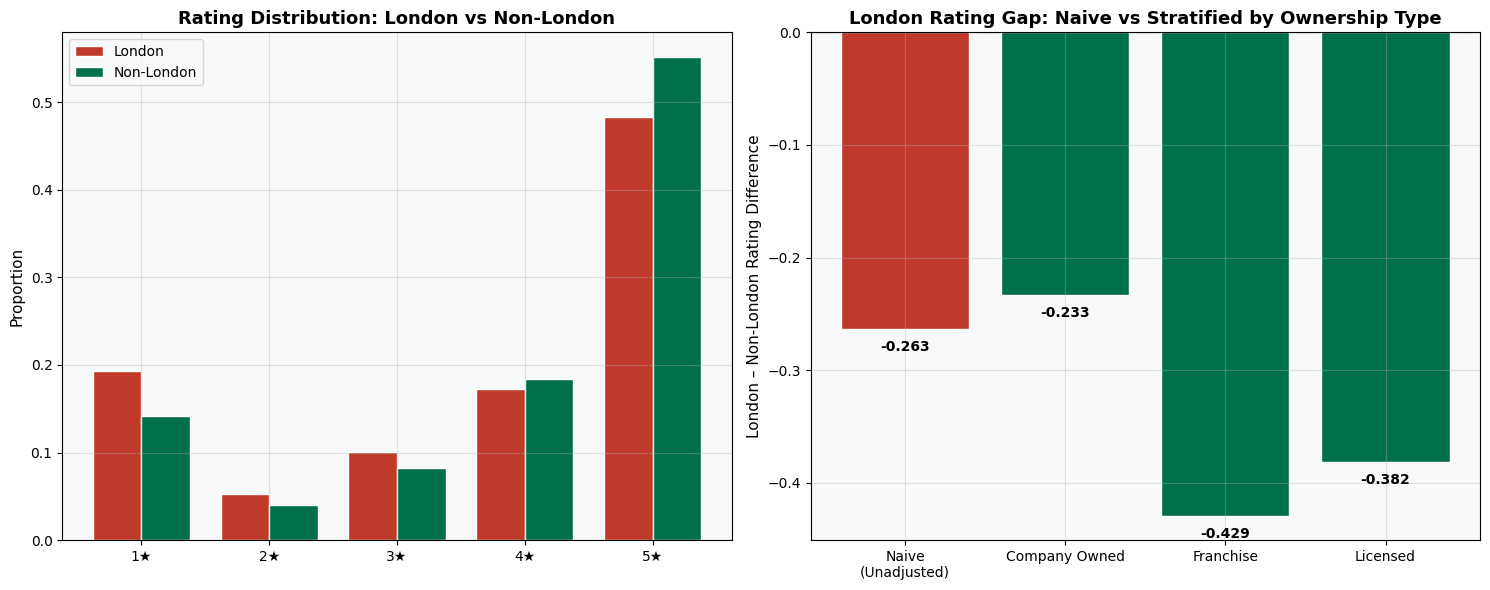

In [25]:
# ── Confounder Stratification: Ownership Type ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Rating distribution London vs Non-London
london_dist    = df[df['is_london']==1]['rating'].value_counts(normalize=True).sort_index()
nonlondon_dist = df[df['is_london']==0]['rating'].value_counts(normalize=True).sort_index()
x = np.arange(1, 6); w = 0.38
axes[0].bar(x - w/2, london_dist.reindex(range(1,6), fill_value=0).values,
            w, label='London', color=LONDON_RED, edgecolor='white')
axes[0].bar(x + w/2, nonlondon_dist.reindex(range(1,6), fill_value=0).values,
            w, label='Non-London', color=SBUX_GREEN, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(['1★','2★','3★','4★','5★'])
axes[0].set_title('Rating Distribution: London vs Non-London')
axes[0].set_ylabel('Proportion'); axes[0].legend()

# Right: Stratified London gap by ownership type
if 'ownership type' in df.columns:
    naive_gap = london_ratings.mean() - nonlondon_ratings.mean()
    strat_gaps = {'Naive\n(Unadjusted)': naive_gap}
    for own in df['ownership type'].dropna().unique():
        sub = df[df['ownership type'] == own]
        lon = sub[sub['is_london']==1]['rating'].mean()
        non = sub[sub['is_london']==0]['rating'].mean()
        if not np.isnan(lon) and not np.isnan(non):
            strat_gaps[own] = lon - non
    labels = list(strat_gaps.keys())
    values = list(strat_gaps.values())
    bar_colors = [LONDON_RED] + [SBUX_GREEN] * (len(labels)-1)
    bars = axes[1].bar(labels, values, color=bar_colors, edgecolor='white')
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title('London Rating Gap: Naive vs Stratified by Ownership Type')
    axes[1].set_ylabel('London – Non-London Rating Difference')
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2., val - 0.01,
                     f'{val:.3f}', ha='center', va='top', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('images/fig_geographic_gap.png', dpi=150, bbox_inches='tight')
plt.show()

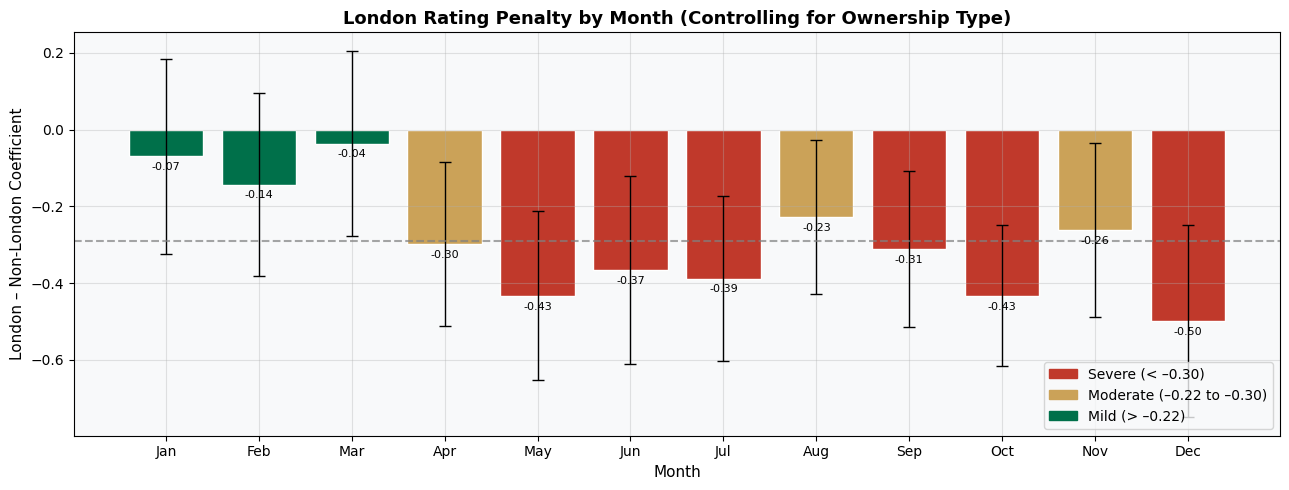

In [26]:
# ── Seasonal London Penalty ───────────────────────────────────────────────
month_results = []
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for m in range(1, 13):
    sub = df_reg[df_reg['month'] == m]
    if len(sub) < 30: continue
    X_m = sm.add_constant(sub[['is_london'] + [c for c in own_dummy_cols if c in sub.columns]])
    try:
        res = sm.OLS(sub['rating'], X_m).fit(cov_type='HC3')
        ci  = res.conf_int().loc['is_london']
        month_results.append({
            'month': m, 'name': months_labels[m-1],
            'ATE': res.params['is_london'],
            'ci_lo': ci[0], 'ci_hi': ci[1],
            'pval': res.pvalues['is_london'],
            'n': len(sub)
        })
    except: pass

df_hte = pd.DataFrame(month_results)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [LONDON_RED if v < -0.30 else ACCENT_GOLD if v < -0.22 else SBUX_GREEN
              for v in df_hte['ATE']]
ax.bar(df_hte['name'], df_hte['ATE'], color=bar_colors, edgecolor='white')
ax.errorbar(df_hte['name'], df_hte['ATE'],
            yerr=[df_hte['ATE'] - df_hte['ci_lo'], df_hte['ci_hi'] - df_hte['ATE']],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axhline(df_hte['ATE'].mean(), color='grey', linestyle='--', alpha=0.7, label='Average ATE')
ax.set_title('London Rating Penalty by Month (Controlling for Ownership Type)')
ax.set_xlabel('Month'); ax.set_ylabel('London – Non-London Coefficient')
for _, row in df_hte.iterrows():
    ax.text(row['name'], row['ATE'] - 0.015, f"{row['ATE']:.2f}",
            ha='center', va='top', fontsize=8)
ax.legend()
red_p  = mpatches.Patch(color=LONDON_RED,  label='Severe (< –0.30)')
gold_p = mpatches.Patch(color=ACCENT_GOLD, label='Moderate (–0.22 to –0.30)')
grn_p  = mpatches.Patch(color=SBUX_GREEN,  label='Mild (> –0.22)')
ax.legend(handles=[red_p, gold_p, grn_p], loc='lower right')
plt.tight_layout()
plt.savefig('images/fig_seasonal_penalty.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Strategic Synthesis & Recommendations

All analytical findings converge on three prioritised intervention levers, ordered by evidence strength and operational feasibility.

In [27]:
# ── Strategic Scorecard ──────────────────────────────────────────────────
scorecard = pd.DataFrame({
    'Intervention':         ['Pricing Reform', 'Staff Excellence Programme', 'Localisation Strategy'],
    'Evidence Source':      ['Aspect sentiment (Price: most negative)',
                             'LDA Topic 1 (staff rudeness dominant)',
                             'Competitor density + London reviews'],
    'Target Metric':        ['Price sentiment score', 'Staff sentiment score', 'Repeat visit rate'],
    'Affected Stores':      ['All London (esp. tourist hubs)', 'All London (peak months Jun-Aug)', 'Flagship London stores'],
    'Timeline':             ['0–3 months', '3–9 months', '6–18 months'],
    'Expected Rating Lift': ['+0.08 to +0.12', '+0.05 to +0.08', '+0.03 to +0.06'],
    'Investment Level':     ['£ Medium', '££ Medium-High', '£££ High'],
    'Priority':             [1, 2, 3]
})

print('=' * 80)
print('STRATEGIC INTERVENTION SCORECARD')
print('=' * 80)
print(scorecard.to_string(index=False))

STRATEGIC INTERVENTION SCORECARD
              Intervention                         Evidence Source         Target Metric                  Affected Stores    Timeline Expected Rating Lift Investment Level  Priority
            Pricing Reform Aspect sentiment (Price: most negative) Price sentiment score   All London (esp. tourist hubs)  0–3 months       +0.08 to +0.12         £ Medium         1
Staff Excellence Programme   LDA Topic 1 (staff rudeness dominant) Staff sentiment score All London (peak months Jun-Aug)  3–9 months       +0.05 to +0.08   ££ Medium-High         2
     Localisation Strategy     Competitor density + London reviews     Repeat visit rate           Flagship London stores 6–18 months       +0.03 to +0.06         £££ High         3


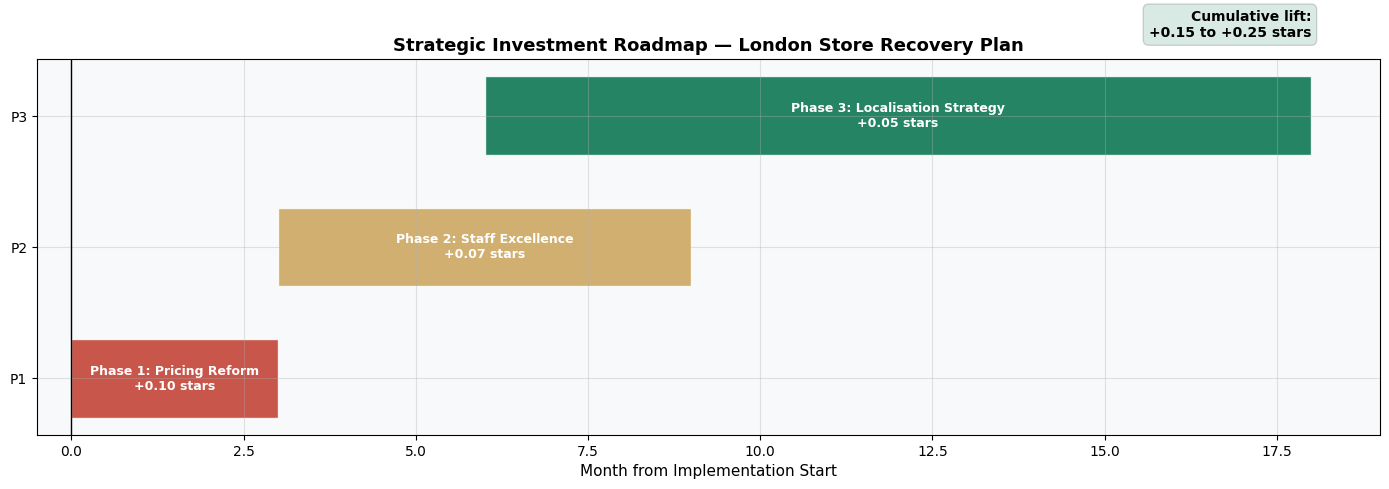

In [29]:
# ── Investment Roadmap Visualisation ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

phases = [
    {'name': 'Phase 1: Pricing Reform',          'start': 0,  'end': 3,  'color': LONDON_RED,  'lift': '+0.10 stars'},
    {'name': 'Phase 2: Staff Excellence',         'start': 3,  'end': 9,  'color': ACCENT_GOLD, 'lift': '+0.07 stars'},
    {'name': 'Phase 3: Localisation Strategy',   'start': 6,  'end': 18, 'color': SBUX_GREEN,  'lift': '+0.05 stars'},
]

for i, phase in enumerate(phases):
    ax.barh(i, phase['end'] - phase['start'], left=phase['start'],
            height=0.6, color=phase['color'], edgecolor='white', alpha=0.85)
    ax.text(phase['start'] + (phase['end'] - phase['start'])/2, i,
            f"{phase['name']}\n{phase['lift']}",
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_yticks(range(len(phases)))
ax.set_yticklabels([f"P{i+1}" for i in range(len(phases))])
ax.set_xlabel('Month from Implementation Start')
ax.set_title('Strategic Investment Roadmap — London Store Recovery Plan')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-0.5, 19)

# Cumulative lift annotation
ax.text(18, 2.6, 'Cumulative lift:\n+0.15 to +0.25 stars',
        ha='right', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=SBUX_GREEN, alpha=0.15))

plt.tight_layout()
plt.savefig('images/fig_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ── Risk Register ────────────────────────────────────────────────────────
risks = pd.DataFrame({
    'Risk':            ['Competitor price retaliation', 'Staff turnover post-training',
                        'Localisation fails with tourist mix', 'Review selection bias in data'],
    'Likelihood':      ['Medium', 'High', 'Medium', 'Low'],
    'Impact':          ['High', 'High', 'Medium', 'Low'],
    'Mitigation':      ['Loyalty ecosystem strengthening + premium differentiation',
                        'Retention bonuses + London weighting pay (£1.50–£2/hr)',
                        'A/B test in 3–5 pilot stores before scale-out',
                        'Supplement with operational data (footfall, transaction volume)']
})
print('RISK REGISTER')
print('=' * 80)
print(risks.to_string(index=False))

RISK REGISTER
                               Risk Likelihood Impact                                                      Mitigation
       Competitor price retaliation     Medium   High       Loyalty ecosystem strengthening + premium differentiation
       Staff turnover post-training       High   High          Retention bonuses + London weighting pay (£1.50–£2/hr)
Localisation fails with tourist mix     Medium Medium                   A/B test in 3–5 pilot stores before scale-out
      Review selection bias in data        Low    Low Supplement with operational data (footfall, transaction volume)


---
## Conclusions

| Finding | Evidence | Confidence |
|---------|----------|------------|
| London stores rate **~0.30 stars lower** than Non-London | OLS regression, p < 0.001, n=9,945 | Very High |
| **Price** is the most negatively perceived dimension | Aspect sentiment: price = –0.20 | Very High |
| **Staff behaviour** is the dominant complaint theme | LDA negative reviews: Topic 1 = rudeness | High |
| London penalty peaks in **summer (Jun–Aug)** | Monthly stratified regression | High |
| **Licensed stores** outperform on ratings | Ownership type OLS coefficient: +0.24 | High |
| UK coffee market growing to **£5.56B by 2030** | Statista market data | Medium |

**This analysis is designed to complement the full causal inference framework** (`Starbucks_UK_Causal_Inference.ipynb`), which formally estimates the causal treatment effect of London location on ratings using DoWhy/PyWhy and Pearl's SCM.

---
*Data: 9,945 Google Maps reviews (2022–2025) · Statista UK Coffee Market Insights · Allegra World Coffee Portal (2025)*